# Reconstrução do TCC — Fase 3: análise exploratória

Este notebook foi criado na reconstrução e implementa **somente a Fase 3**. Ele usa a tese como fonte primária, reaproveita de forma adaptada as células 8–20 e 49–51 do notebook recuperado e consome o pipeline novo da Fase 2.

**Proveniência:** código e narrativa novos, exceto quando uma célula identifica explicitamente uma adaptação. Os dois notebooks recuperados permanecem imutáveis. Não há imputação, codificação, balanceamento ou modelagem nesta fase.

**Privacidade e reprodutibilidade:** as tabelas mostram apenas agregados por coluna; nenhuma linha de cliente é exibida ou armazenada nos outputs.

## Configuração e carregamento

**Origem:** tese, seção 4.2; notebook recuperado, células 6–9 e 26; pipeline novo da Fase 2.  
**Tipo:** adaptado.  
**Mudança:** caminho configurável, validação de esquema, leitura em blocos, conversões estritas e filtros auditáveis.  
**População base das Figuras 9–15:** `Fully Paid`, `Charged Off` e `Default`, sem filtro de verificação.  
**População das Figuras 16–19:** a população base restrita a `Verified` e `Source Verified`.

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns

from tcc_reconstruction.data import (
    DATA_PATH_ENV,
    DataPipelineConfig,
    VERIFIED_INCOME_STATUSES,
    inspect_schema,
    run_data_pipeline,
)
from tcc_reconstruction.eda import (
    FIGURE_TITLES,
    add_log1p_columns,
    aggregate_column_profile,
    calculate_pearson_correlations,
    deterministic_plot_sample,
    select_defaulted_loans,
)

SEED = 42
PLOT_SAMPLE_SIZE = 100_000
DEFAULT_DATASET = Path("data/raw/Loan_status_2007-2020Q3.gzip")
DATASET_PATH = Path(os.environ.get(DATA_PATH_ENV, DEFAULT_DATASET))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 10)

In [2]:
pipeline_result = run_data_pipeline(
    DataPipelineConfig(
        dataset_path=DATASET_PATH,
        sample_size=None,
        random_seed=SEED,
        verified_only=False,
    )
)
all_loans = pipeline_result.data
verified_loans = all_loans[
    all_loans["verification_status"].isin(VERIFIED_INCOME_STATUSES)
]

population_summary = pd.DataFrame(
    {
        "população": [
            "arquivo bruto",
            "status finais (Figuras 9–15)",
            "status finais + renda verificada (Figuras 16–19)",
        ],
        "registros": [
            pipeline_result.summary.rows_read,
            len(all_loans),
            len(verified_loans),
        ],
    }
)
population_summary

,população,registros
0,arquivo bruto,2925493
1,status finais (Figuras 9–15),1860764
2,status finais + renda verificada (Figuras 16–19),1272273


In [3]:
plot_sample_all = deterministic_plot_sample(
    all_loans, sample_size=PLOT_SAMPLE_SIZE, seed=SEED
)
plot_sample_verified = deterministic_plot_sample(
    verified_loans, sample_size=PLOT_SAMPLE_SIZE, seed=SEED
)
plot_sample_verified = add_log1p_columns(plot_sample_verified)

sampling_summary = pd.DataFrame(
    {
        "uso": ["Figuras 9–15", "Figuras 16–19"],
        "população_para_métricas": [len(all_loans), len(verified_loans)],
        "amostra_somente_para_renderização": [
            len(plot_sample_all),
            len(plot_sample_verified),
        ],
        "semente": [SEED, SEED],
    }
)
sampling_summary

,uso,população_para_métricas,amostra_somente_para_renderização,semente
0,Figuras 9–15,1860764,100000,42
1,Figuras 16–19,1272273,100000,42


## Figura 9 — Distribuição do Montante de Empréstimo por Ano

**Origem:** tese, Figura 9; notebook recuperado, células 19–20.  
**Tipo:** adaptado.  
**População:** empréstimos nos três status finais, exceto 2020, que é um ano incompleto no arquivo Q3. O boxplot usa a amostra determinística apenas para limitar o custo de renderização; as contagens e correlações desta análise usam as populações completas.

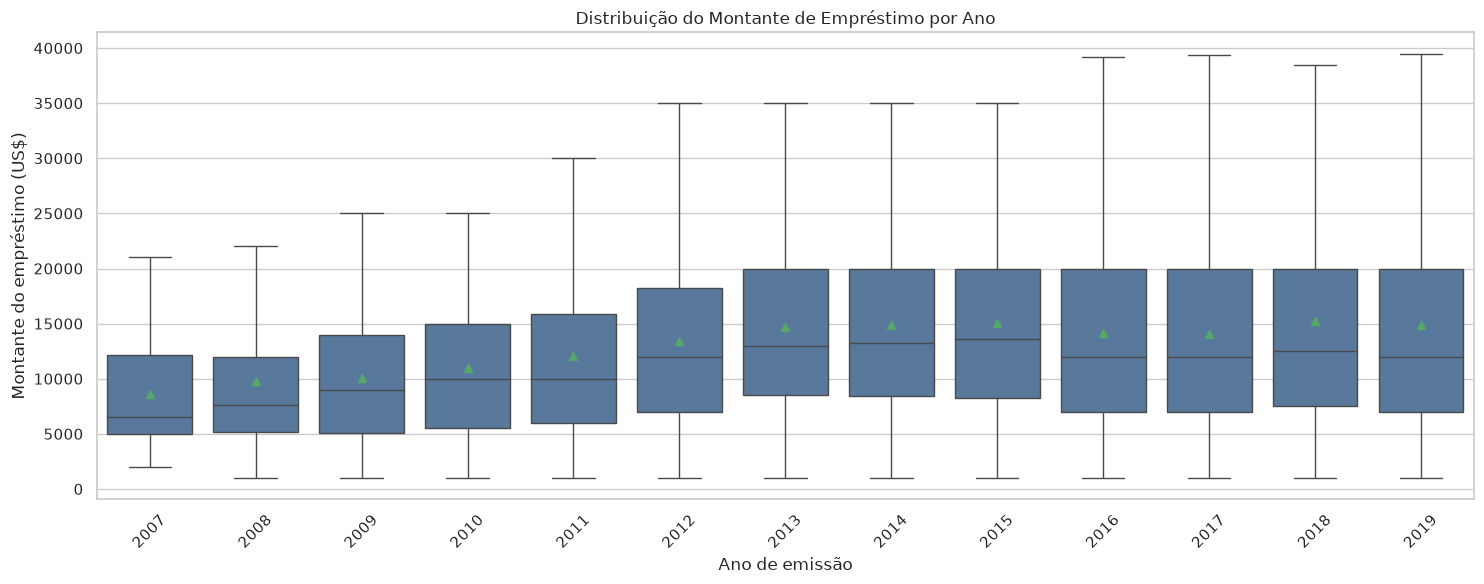

In [4]:
figure_9_data = plot_sample_all[plot_sample_all["year"] != 2020]
plt.figure(figsize=(15, 6))
ax = sns.boxplot(
    data=figure_9_data,
    x="year",
    y="loan_amnt",
    color="#4c78a8",
    showmeans=True,
    showfliers=False,
)
ax.set(
    title=FIGURE_TITLES[9],
    xlabel="Ano de emissão",
    ylabel="Montante do empréstimo (US$)",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Figuras 10–12 — Correlações de Pearson

**Origem:** tese, Figuras 10–12; ausentes no notebook recuperado.  
**Tipo:** novo.  
**População:** empréstimos nos três status finais; cada coeficiente usa todos os pares não ausentes. A amostra determinística é usada somente para desenhar os pontos. Os valores são recalculados abaixo e não são fixados em texto.

In [5]:
correlations = calculate_pearson_correlations(all_loans)
correlations

,variavel_x,variavel_y,n_pares_validos,correlacao_pearson
0,loan_amnt,funded_amnt,1860764,0.999700
1,fico_range_low,fico_range_high,1860764,1.000000
2,total_acc,open_acc,1860764,0.708775


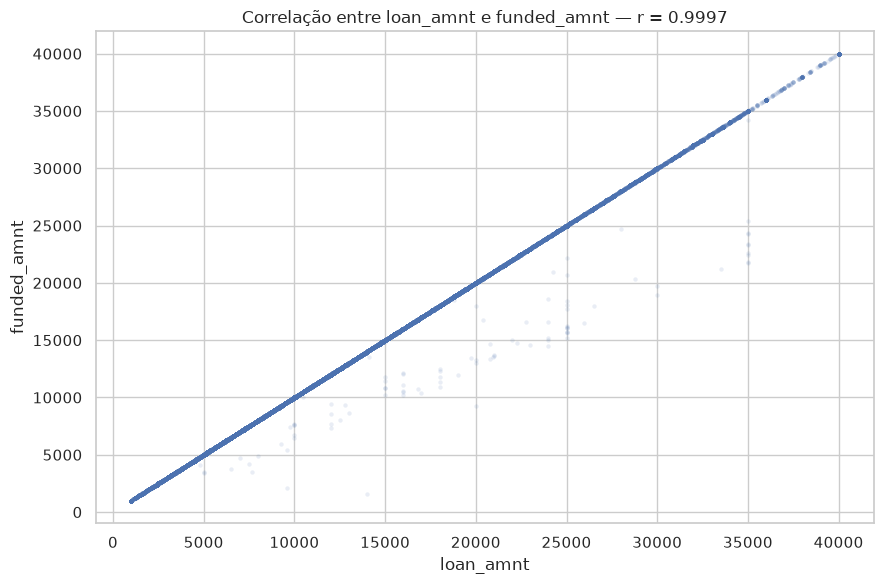

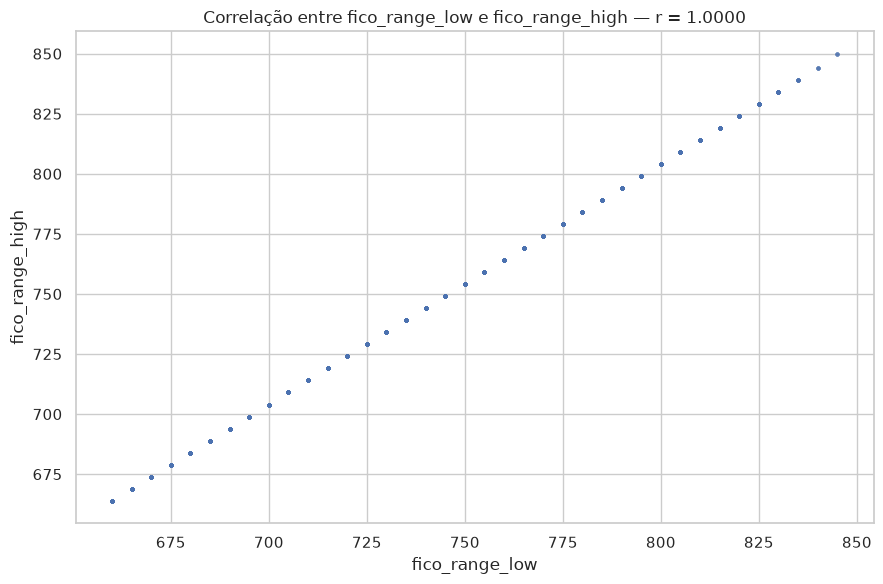

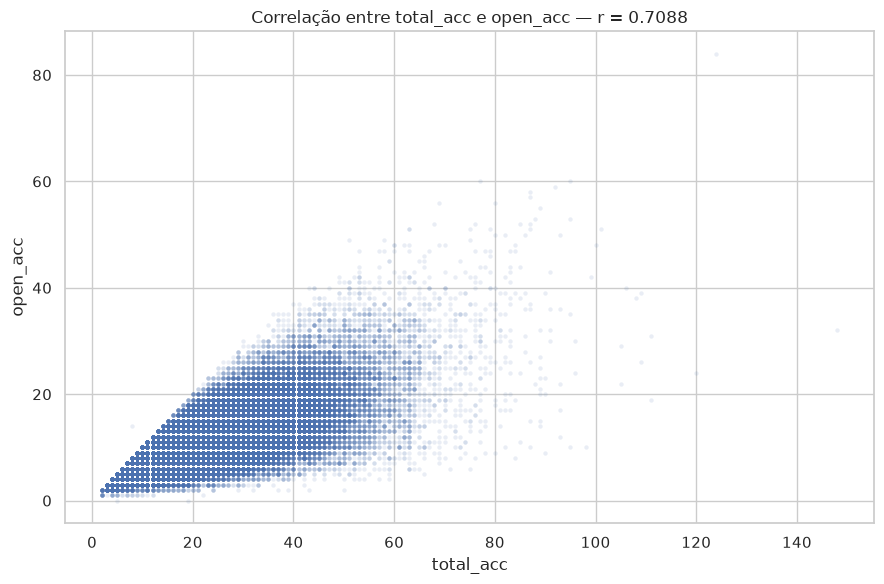

In [6]:
correlation_figures = [
    (10, "loan_amnt", "funded_amnt"),
    (11, "fico_range_low", "fico_range_high"),
    (12, "total_acc", "open_acc"),
]

for figure_number, x_column, y_column in correlation_figures:
    correlation = correlations.loc[
        (correlations["variavel_x"] == x_column)
        & (correlations["variavel_y"] == y_column),
        "correlacao_pearson",
    ].iloc[0]
    chart_data = plot_sample_all[[x_column, y_column]].dropna()
    plt.figure(figsize=(9, 6))
    ax = sns.scatterplot(
        data=chart_data,
        x=x_column,
        y=y_column,
        alpha=0.12,
        s=10,
        linewidth=0,
    )
    ax.set_title(f"{FIGURE_TITLES[figure_number]} — r = {correlation:.4f}")
    plt.tight_layout()
    plt.show()

## Figura 13 — Gráfico de Barras das Razões de Inadimplência

**Origem:** tese, Figura 13; notebook recuperado, células 11–12.  
**Tipo:** adaptado com correção metodológica.  
**Mudança:** o código recuperado contava também empréstimos pagos.  
**População:** somente `Charged Off` e `Default`, sem filtro de verificação de renda.

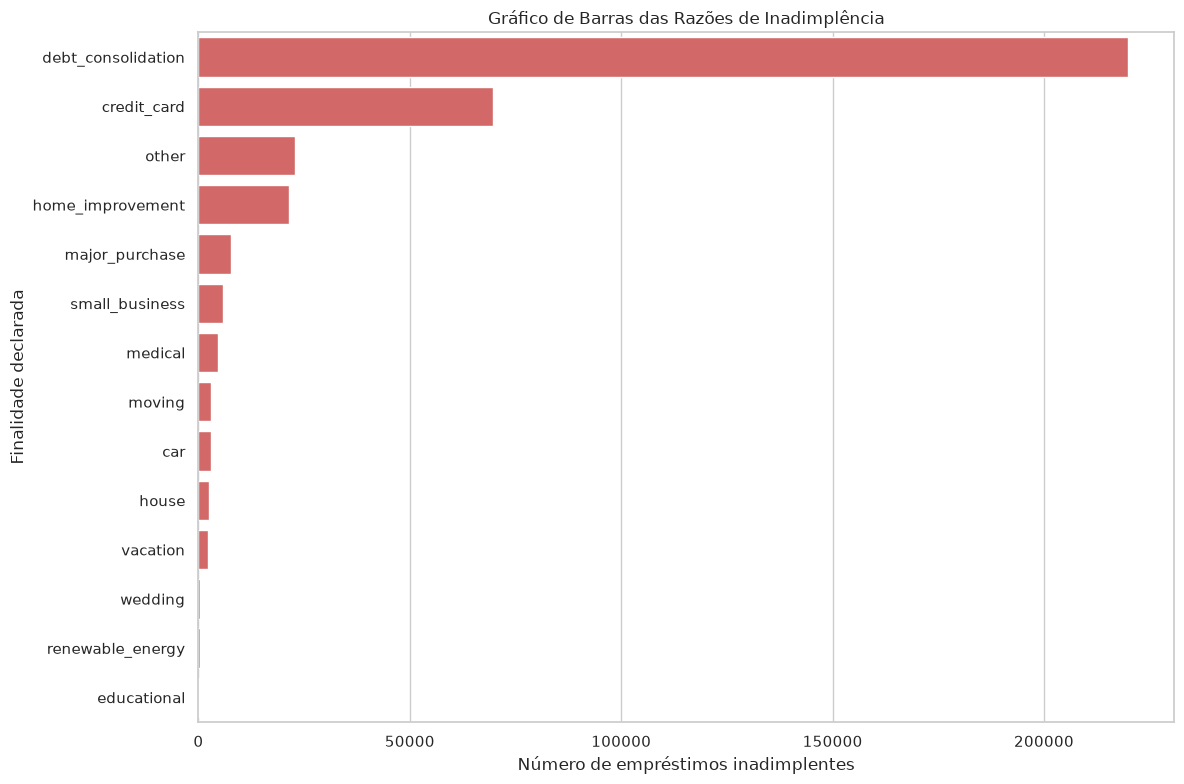

,inadimplentes
finalidade,
debt_consolidation,219761
credit_card,69656
other,22775
home_improvement,21357
major_purchase,7720
small_business,5868
medical,4613
moving,2917
car,2858


In [7]:
defaulted_loans = select_defaulted_loans(all_loans)
purpose_counts = (
    defaulted_loans["purpose"]
    .astype("string")
    .fillna("<ausente>")
    .value_counts()
    .rename_axis("finalidade")
    .rename("inadimplentes")
)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x=purpose_counts.values,
    y=purpose_counts.index,
    color="#e45756",
)
ax.set(
    title=FIGURE_TITLES[13],
    xlabel="Número de empréstimos inadimplentes",
    ylabel="Finalidade declarada",
)
plt.tight_layout()
plt.show()
purpose_counts.to_frame()

## Figura 14 — Mapa Coroplético de Empréstimos por Estado

**Origem:** tese, Figura 14; notebook recuperado, células 13–15.  
**Tipo:** adaptado para Plotly atual.  
**População:** empréstimos nos três status finais, sem filtro de verificação de renda.

In [8]:
state_counts = (
    all_loans["addr_state"]
    .astype("string")
    .dropna()
    .value_counts()
    .rename_axis("estado")
    .rename("empréstimos")
    .reset_index()
)

figure_14 = go.Figure(
    data=go.Choropleth(
        locations=state_counts["estado"],
        z=state_counts["empréstimos"],
        locationmode="USA-states",
        colorscale="Cividis",
        colorbar_title="Empréstimos",
    )
)
figure_14.update_layout(
    title=FIGURE_TITLES[14],
    geo_scope="usa",
    height=550,
)
figure_14.show()

## Figura 15 — Distribuição da Relação Dívida/Renda (DTI)

**Origem:** tese, Figura 15; notebook recuperado, células 16–18.  
**Tipo:** adaptado; `histplot` substitui APIs obsoletas.  
**População:** empréstimos nos três status finais com DTI não ausente. O resumo usa toda a população. Para tornar a concentração central legível, o histograma exclui o sentinela negativo e limita visualmente o eixo ao percentil 99; os valores excluídos continuam contabilizados no resumo.

In [9]:
dti_non_null = all_loans["dti"].dropna()
dti_summary = all_loans["dti"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("dti")
dti_anomalies = pd.DataFrame(
    {
        "regra": ["ausente", "negativo (sentinela/anomalia)", "acima do percentil 99"],
        "registros": [
            int(all_loans["dti"].isna().sum()),
            int((dti_non_null < 0).sum()),
            int((dti_non_null > dti_non_null.quantile(0.99)).sum()),
        ],
    }
)
display(dti_summary)
display(dti_anomalies)

,dti
count,1.859655e+06
mean,1.856806e+01
std,1.309105e+01
min,-1.000000e+00
50%,1.771000e+01
90%,3.015000e+01
95%,3.345000e+01
99%,3.961000e+01
max,9.990000e+02


,regra,registros
0,ausente,1109
1,negativo (sentinela/anomalia),2
2,acima do percentil 99,18561


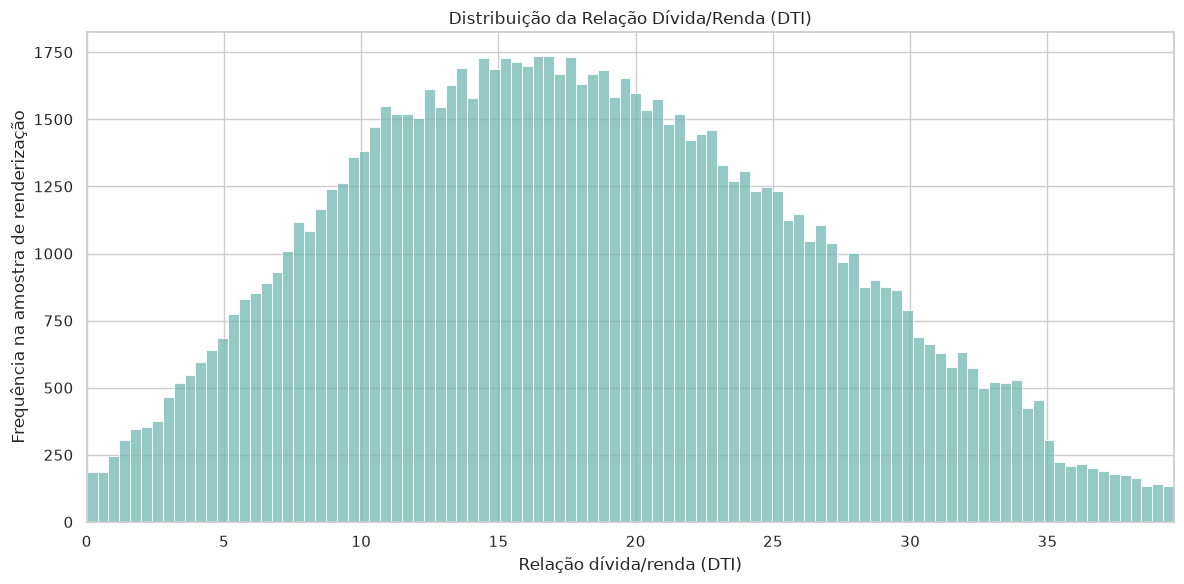

In [10]:
figure_15_limit = dti_non_null[dti_non_null >= 0].quantile(0.99)
figure_15_data = plot_sample_all[
    plot_sample_all["dti"].between(0, figure_15_limit, inclusive="both")
]
plt.figure(figsize=(12, 6))
ax = sns.histplot(
    data=figure_15_data,
    x="dti",
    bins=100,
    color="#72b7b2",
)
ax.set_xlim(0, figure_15_limit)
ax.set(
    title=FIGURE_TITLES[15],
    xlabel="Relação dívida/renda (DTI)",
    ylabel="Frequência na amostra de renderização",
)
plt.tight_layout()
plt.show()

## Figuras 16–17 — Renda anual antes e depois de `log1p`

**Origem:** tese, Figuras 16–17; notebook recuperado, células 49 e 51.  
**Tipo:** adaptado; `histplot` com densidade substitui `distplot`.  
**População:** empréstimos nos três status finais com renda `Verified` ou `Source Verified`; valores ausentes são ignorados. A transformação é uma cópia analítica e não altera o pipeline da Fase 2. Para evitar que poucos extremos ocultem o formato, cada eixo mostra os percentis 0,5–99,5 da respectiva variável; os perfis tabulares preservam os extremos completos.

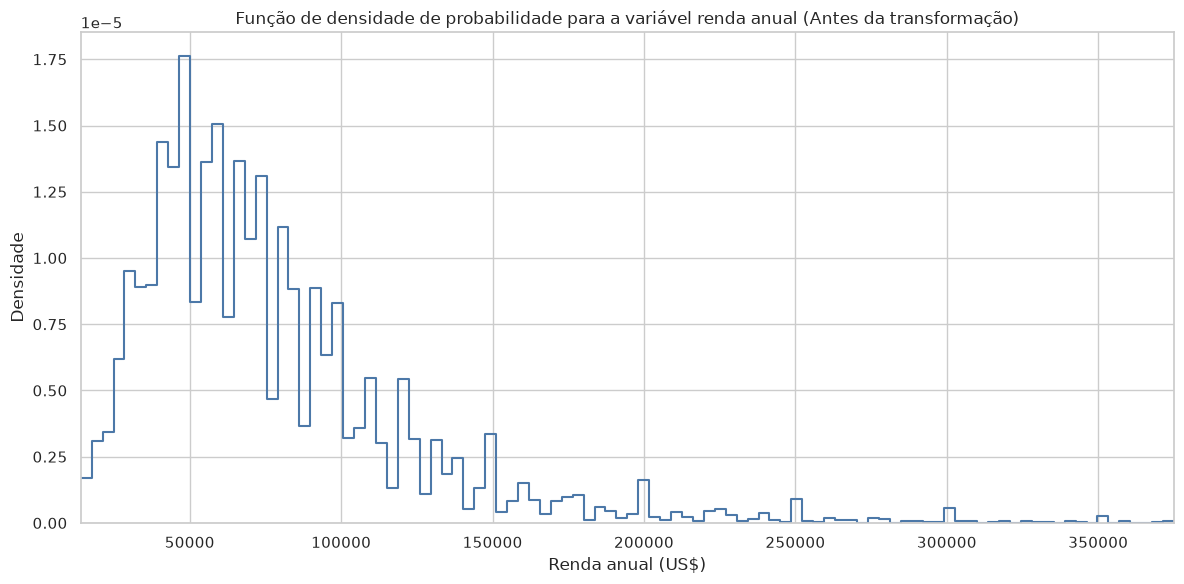

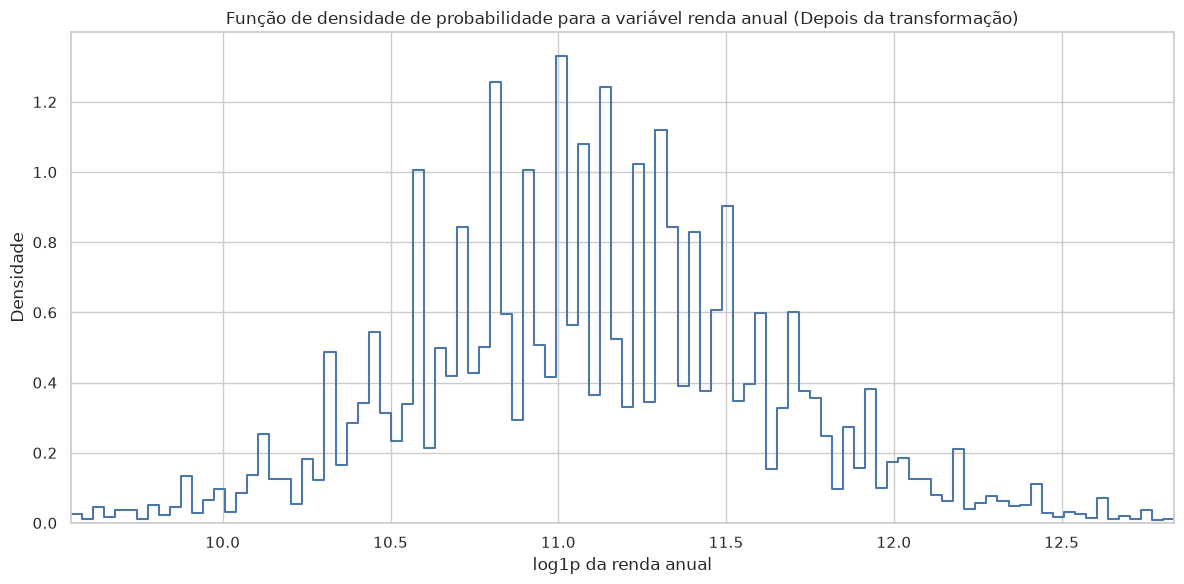

In [11]:
for figure_number, column, xlabel in (
    (16, "annual_inc", "Renda anual (US$)"),
    (17, "annual_inc_log1p", "log1p da renda anual"),
):
    lower, upper = plot_sample_verified[column].quantile([0.005, 0.995])
    chart_data = plot_sample_verified[
        plot_sample_verified[column].between(lower, upper, inclusive="both")
    ]
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=chart_data,
        x=column,
        bins=100,
        stat="density",
        element="step",
        fill=False,
        color="#4c78a8",
    )
    ax.set(
        title=FIGURE_TITLES[figure_number],
        xlabel=xlabel,
        ylabel="Densidade",
    )
    ax.set_xlim(lower, upper)
    plt.tight_layout()
    plt.show()

## Figuras 18–19 — Linhas de crédito abertas antes e depois de `log1p`

**Origem:** tese, Figuras 18–19; notebook recuperado, células 50–51.  
**Tipo:** adaptado; `histplot` substitui `distplot`.  
**População:** empréstimos nos três status finais com renda `Verified` ou `Source Verified`; valores ausentes são ignorados. A transformação é uma cópia analítica e não antecipa o pré-processamento do modelo.

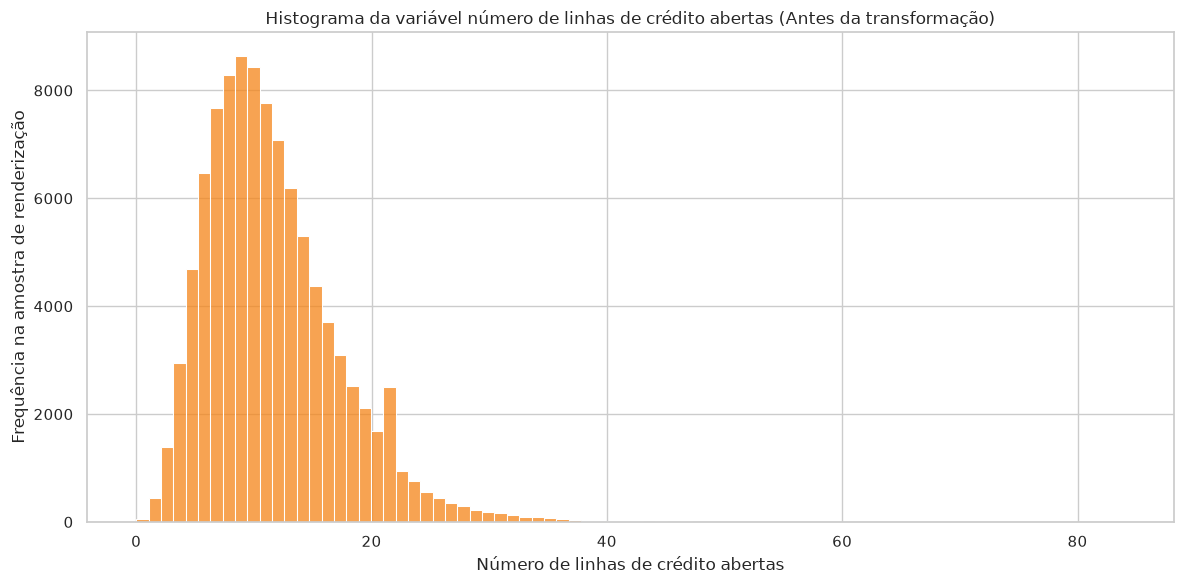

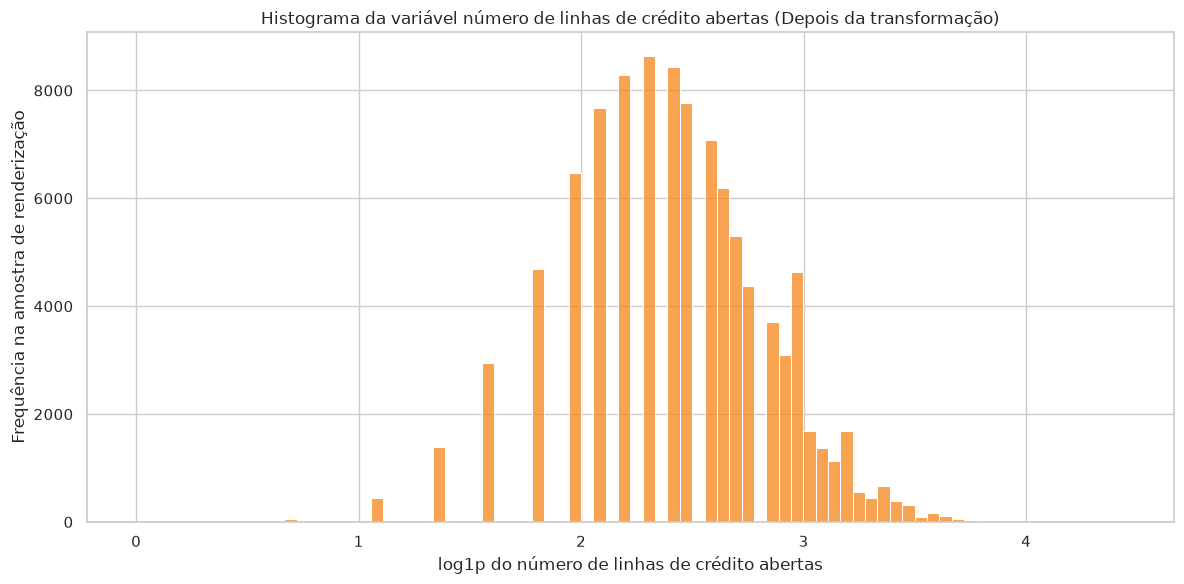

In [12]:
for figure_number, column, xlabel in (
    (18, "open_acc", "Número de linhas de crédito abertas"),
    (19, "open_acc_log1p", "log1p do número de linhas de crédito abertas"),
):
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data=plot_sample_verified,
        x=column,
        bins=80,
        color="#f58518",
    )
    ax.set(
        title=FIGURE_TITLES[figure_number],
        xlabel=xlabel,
        ylabel="Frequência na amostra de renderização",
    )
    plt.tight_layout()
    plt.show()

## Tabelas 3–6 — dados antes/depois do processamento

**Origem:** tese, Tabelas 3–6.  
**Tipo:** adaptado por segurança.  
**Mudança:** a tese publica cinco linhas individuais. A reconstrução registra a posição e o tratamento das dez colunas originais e perfis agregados das dez colunas correspondentes após os filtros/conversões da Fase 2. Nenhum identificador ou registro individual é exibido. Codificação e imputação permanecem para a Fase 5.

In [13]:
raw_columns = list(inspect_schema(DATASET_PATH))
first_ten_columns = raw_columns[:10]
raw_schema_audit = pd.DataFrame(
    {
        "posição_original": range(1, 11),
        "coluna": first_ten_columns,
        "disponível_no_pipeline_fase_2": [column in all_loans.columns for column in first_ten_columns],
    }
)

table_3 = raw_schema_audit.iloc[:5].reset_index(drop=True)
table_4 = raw_schema_audit.iloc[5:10].reset_index(drop=True)
display(table_3)
display(table_4)

,posição_original,coluna,disponível_no_pipeline_fase_2
0,1,Unnamed: 0,False
1,2,id,True
2,3,loan_amnt,True
3,4,funded_amnt,True
4,5,funded_amnt_inv,False


,posição_original,coluna,disponível_no_pipeline_fase_2
0,6,term,True
1,7,int_rate,True
2,8,installment,True
3,9,grade,True
4,10,sub_grade,True


In [14]:
processed_columns = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "open_acc",
    "total_acc",
    "fico_range_low",
    "fico_range_high",
]
processed_profile = aggregate_column_profile(verified_loans, processed_columns)
table_5 = processed_profile.iloc[:5].reset_index(drop=True)
table_6 = processed_profile.iloc[5:10].reset_index(drop=True)
display(table_5)
display(table_6)

,coluna,tipo,não_nulos,ausentes,mínimo,mediana,máximo
0,loan_amnt,float64,1272273,0,1000.00,14000.00,4.000000e+04
1,funded_amnt,float64,1272273,0,1000.00,14000.00,4.000000e+04
2,int_rate,Float64,1272273,0,5.31,13.35,3.099000e+01
3,installment,float64,1272273,0,4.93,402.83,1.719830e+03
4,annual_inc,float64,1272273,0,0.00,65000.00,1.100000e+08


,coluna,tipo,não_nulos,ausentes,mínimo,mediana,máximo
0,dti,float64,1272149,124,-1.0,18.0,999.0
1,open_acc,float64,1272273,0,0.0,11.0,90.0
2,total_acc,float64,1272273,0,2.0,23.0,176.0
3,fico_range_low,float64,1272273,0,660.0,685.0,845.0
4,fico_range_high,float64,1272273,0,664.0,689.0,850.0


## Resultados observados e limites da Fase 3

Os valores abaixo são calculados na execução atual com o dataset real. Eles sustentam a atualização de `docs/result-comparison.md` sem fabricar equivalência com as figuras publicadas.

Limites: os gráficos densos usam uma amostra determinística de 100.000 somente para renderização; correlações, contagens e perfis tabulares usam a população completa. A transformação `log1p` é exploratória e não constitui ajuste de um pipeline de modelo.

In [15]:
observed_results = correlations.copy()
observed_results["correlacao_tese"] = [1.00, 1.00, 0.71]
observed_results["diferença"] = (
    observed_results["correlacao_pearson"] - observed_results["correlacao_tese"]
)
observed_results

,variavel_x,variavel_y,n_pares_validos,correlacao_pearson,correlacao_tese,diferença
0,loan_amnt,funded_amnt,1860764,0.999700,1.00,-2.998806e-04
1,fico_range_low,fico_range_high,1860764,1.000000,1.00,-7.658783e-08
2,total_acc,open_acc,1860764,0.708775,0.71,-1.224766e-03


# Fase 4 — PoC 1: recomendação baseada em conteúdo

**Origem:** tese, seção 4.4, Figuras 20–22 e Tabela 7. Esta PoC está ausente do notebook recuperado.  
**Tipo:** código novo de reconstrução, com uma versão forense fiel aos números publicados e uma adaptação normalizada.  
**Atributos:** `annual_inc`, `all_util`, `acc_open_past_24mths` e `grade`.  
**População:** amostra determinística de 10.000 empréstimos após os filtros de status e renda verificada da Fase 2, semente 42.  
**Limiar:** distância ≤ 20; a igualdade qualifica. Valores ausentes nunca qualificam.

A nota é codificada ordinalmente como A=1, B=2, ..., G=7. As fronteiras de elegibilidade são inclusivas. A distância bruta usa as escalas originais e, portanto, é dominada pela renda anual.

## Campanhas e divergência da fonte

- **Campanha 1:** renda ≥ 30.000; utilização ≤ 60%; ao menos 1 conta aberta em 24 meses; grade B–E.
- **Campanha 2:** renda ≥ 60.000; utilização ≤ 35%; ao menos 5 contas abertas em 24 meses; grade A–C.

A elegibilidade sempre conserva o máximo de 35% da Campanha 2. Entretanto, as quatro distâncias da Tabela 7 só são reproduzidas quando a referência de utilização dentro da distância da Campanha 2 é 40. A reconstrução mantém essa referência apenas no cálculo forense e também calcula a alternativa estrita com referência 35.

In [16]:
from tcc_reconstruction.poc1 import (
    CAMPAIGN_1,
    CAMPAIGN_2,
    CAMPAIGN_2_STRICT,
    DEFAULT_DISTANCE_THRESHOLD,
    evaluate_campaign,
    reproduce_table_7,
    robust_component_scales,
)

campaign_rules = pd.DataFrame(
    [
        {
            "campanha": CAMPAIGN_1.name,
            "renda_mínima": CAMPAIGN_1.minimum_annual_income,
            "utilização_máxima": CAMPAIGN_1.maximum_utilization,
            "contas_mínimas_24m": CAMPAIGN_1.minimum_recent_accounts,
            "grades": "B–E",
            "referência_utilização_distância": CAMPAIGN_1.distance_utilization_reference,
        },
        {
            "campanha": CAMPAIGN_2.name,
            "renda_mínima": CAMPAIGN_2.minimum_annual_income,
            "utilização_máxima": CAMPAIGN_2.maximum_utilization,
            "contas_mínimas_24m": CAMPAIGN_2.minimum_recent_accounts,
            "grades": "A–C",
            "referência_utilização_distância": CAMPAIGN_2.distance_utilization_reference,
        },
    ]
)
campaign_rules

,campanha,renda_mínima,utilização_máxima,contas_mínimas_24m,grades,referência_utilização_distância
0,Campanha 1,30000.0,60.0,1.0,B–E,60.0
1,Campanha 2,60000.0,35.0,5.0,A–C,40.0


## Tabela 7 — Resultados da Prova de Conceito

Os perfis Vinicius e Elder são exemplos sintéticos publicados na tese. A tabela abaixo reproduz as distâncias sem atribuí-las a registros reais do dataset.

In [17]:
table_7 = reproduce_table_7()
strict_campaign_2_examples = evaluate_campaign(table_7, CAMPAIGN_2_STRICT)
table_7_comparison = table_7.copy()
table_7_comparison["campaign_2_distance_strict_35"] = strict_campaign_2_examples["distance"]
table_7_comparison

,user_id,annual_inc,all_util,acc_open_past_24mths,grade,campaign_1_distance,campaign_1_qualified,campaign_2_distance,campaign_2_qualified,campaign_2_distance_strict_35
0,Vinicius,30000.0,55.0,1.0,C,5.000000,True,30000.004017,False,30000.006933
1,Elder,60000.0,35.0,5.0,A,30000.010433,False,5.000000,True,0.000000


## Execução na amostra determinística real

**Tipo:** novo.  
**Regra principal:** um perfil só é aprovado quando satisfaz todos os critérios declarados **e** possui distância bruta ≤ 20. Para diagnosticar os números publicados, também é contabilizado o resultado histórico que aplica somente a distância ≤ 20.

In [18]:
poc1_pipeline = run_data_pipeline(
    DataPipelineConfig(
        dataset_path=DATASET_PATH,
        sample_size=10_000,
        random_seed=SEED,
        verified_only=True,
    )
)
poc1_data = poc1_pipeline.data
poc1_features = ["annual_inc", "all_util", "acc_open_past_24mths", "grade"]

poc1_population = pd.DataFrame(
    {
        "métrica": ["amostra", *[f"ausentes: {column}" for column in poc1_features]],
        "registros": [
            len(poc1_data),
            *[int(poc1_data[column].isna().sum()) for column in poc1_features],
        ],
    }
)
poc1_population

,métrica,registros
0,amostra,10000
1,ausentes: annual_inc,0
2,ausentes: all_util,4716
3,ausentes: acc_open_past_24mths,237
4,ausentes: grade,0


In [19]:
normalization_scales = robust_component_scales(poc1_data)

campaign_1_raw = evaluate_campaign(poc1_data, CAMPAIGN_1)
campaign_2_raw = evaluate_campaign(poc1_data, CAMPAIGN_2)
campaign_2_strict = evaluate_campaign(poc1_data, CAMPAIGN_2_STRICT)
campaign_1_normalized = evaluate_campaign(
    poc1_data, CAMPAIGN_1, scales=normalization_scales
)
campaign_2_normalized = evaluate_campaign(
    poc1_data, CAMPAIGN_2, scales=normalization_scales
)

campaign_summary = pd.DataFrame(
    {
        "campanha": ["Campanha 1", "Campanha 2"],
        "elegíveis_pelos_critérios": [
            int(campaign_1_raw["eligible"].sum()),
            int(campaign_2_raw["eligible"].sum()),
        ],
        "aprovados_critérios_e_distância_bruta": [
            int(campaign_1_raw["qualified"].sum()),
            int(campaign_2_raw["qualified"].sum()),
        ],
        "somente_distância_bruta": [
            int(campaign_1_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
            int(campaign_2_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
        ],
        "critérios_e_distância_normalizada_≤20": [
            int(campaign_1_normalized["qualified"].sum()),
            int(campaign_2_normalized["qualified"].sum()),
        ],
    }
)

strict_comparison = pd.DataFrame(
    {
        "versão_Campanha_2": ["referência forense 40", "referência estrita 35"],
        "aprovados_critérios_e_distância_bruta": [
            int(campaign_2_raw["qualified"].sum()),
            int(campaign_2_strict["qualified"].sum()),
        ],
        "somente_distância_bruta": [
            int(campaign_2_raw["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
            int(campaign_2_strict["distance"].le(DEFAULT_DISTANCE_THRESHOLD).sum()),
        ],
    }
)
display(normalization_scales.rename("IQR usado na normalização").to_frame())
display(campaign_summary)
display(strict_comparison)

,IQR usado na normalização
annual_inc,49000.0
all_util,27.0
acc_open_past_24mths,4.0
grade,2.0


,campanha,elegíveis_pelos_critérios,aprovados_critérios_e_distância_bruta,somente_distância_bruta,critérios_e_distância_normalizada_≤20
0,Campanha 1,1790,36,64,1790
1,Campanha 2,178,10,88,178


,versão_Campanha_2,aprovados_critérios_e_distância_bruta,somente_distância_bruta
0,referência forense 40,10,88
1,referência estrita 35,11,72


## Figura 20 — Total de aprovados em cada campanha

**População e regra:** amostra determinística de 10.000; critérios inclusivos declarados na tese e distância bruta ≤ 20. Os totais históricos baseados somente na distância permanecem na tabela anterior, não são apresentados como aprovações conformes.

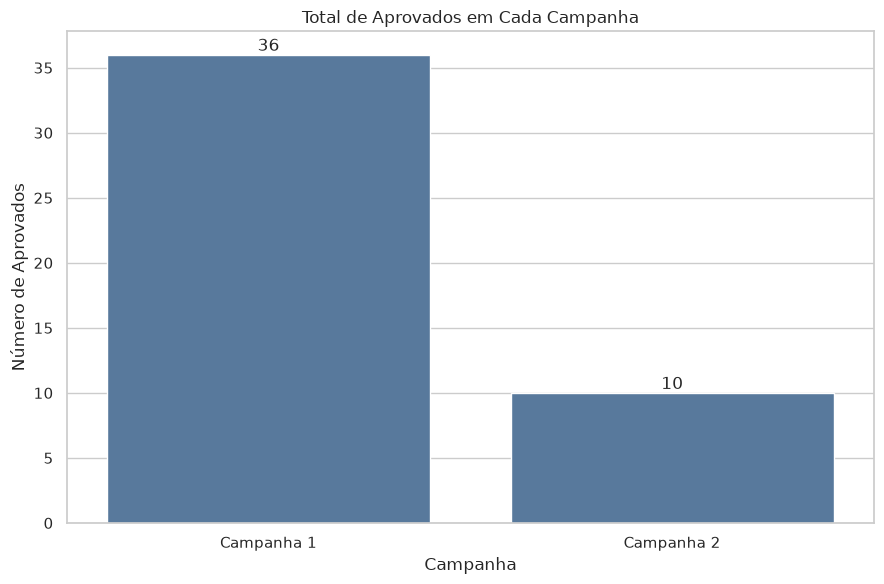

In [20]:
figure_20_data = campaign_summary[
    ["campanha", "aprovados_critérios_e_distância_bruta"]
].rename(columns={"aprovados_critérios_e_distância_bruta": "aprovados"})

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=figure_20_data, x="campanha", y="aprovados", color="#4c78a8")
ax.set(
    title="Total de Aprovados em Cada Campanha",
    xlabel="Campanha",
    ylabel="Número de Aprovados",
)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## Figuras 21–22 — pontuação por distância

**Origem:** tese, Figuras 21–22.  
**Tipo:** reconstruído com API atual.  
**População:** os perfis da amostra com os quatro atributos presentes. A linha vermelha marca o limiar inclusivo 20. Os histogramas preservam a distância bruta e evidenciam o domínio da renda anual.

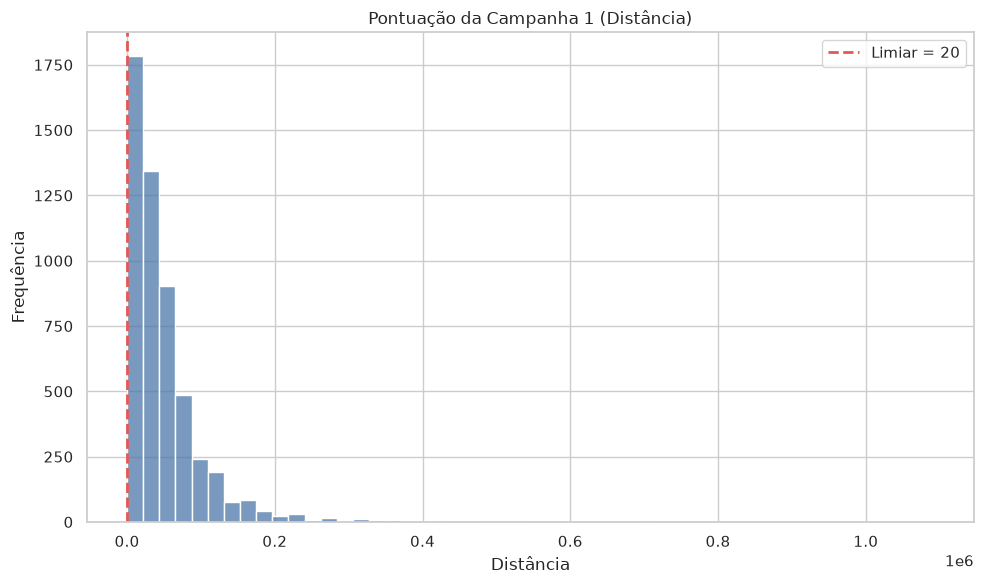

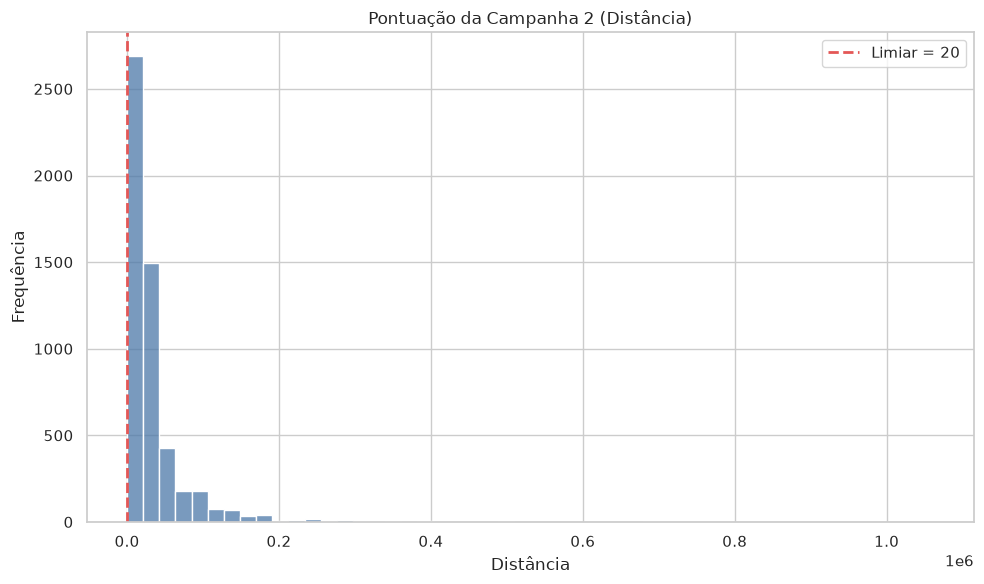

In [21]:
for figure_number, title, evaluation in (
    (21, "Pontuação da Campanha 1 (Distância)", campaign_1_raw),
    (22, "Pontuação da Campanha 2 (Distância)", campaign_2_raw),
):
    distances = evaluation["distance"].dropna()
    plt.figure(figsize=(10, 6))
    ax = sns.histplot(distances, bins=50, color="#4c78a8")
    ax.axvline(
        DEFAULT_DISTANCE_THRESHOLD,
        color="#e45756",
        linestyle="--",
        linewidth=2,
        label="Limiar = 20",
    )
    ax.set(title=title, xlabel="Distância", ylabel="Frequência")
    ax.legend()
    plt.tight_layout()
    plt.show()

## Sensibilidade — distância bruta versus normalizada

**Tipo:** adaptação nova. A normalização divide cada componente pelo intervalo interquartil observado na própria amostra. Isso evita o domínio numérico da renda, mas altera completamente a escala: reutilizar o limiar bruto 20 aprova todos os perfis elegíveis. Portanto, um limiar normalizado precisaria ser calibrado com objetivo de negócio ou validação externa; ele não é inventado nesta fase.

In [22]:
distance_comparison = pd.DataFrame(
    {
        "campanha": ["Campanha 1", "Campanha 2"],
        "mediana_distância_bruta": [
            campaign_1_raw["distance"].median(),
            campaign_2_raw["distance"].median(),
        ],
        "mediana_distância_normalizada": [
            campaign_1_normalized["distance"].median(),
            campaign_2_normalized["distance"].median(),
        ],
        "aprovados_bruta_≤20_com_critérios": [
            int(campaign_1_raw["qualified"].sum()),
            int(campaign_2_raw["qualified"].sum()),
        ],
        "aprovados_normalizada_≤20_com_critérios": [
            int(campaign_1_normalized["qualified"].sum()),
            int(campaign_2_normalized["qualified"].sum()),
        ],
    }
)
distance_comparison

,campanha,mediana_distância_bruta,mediana_distância_normalizada,aprovados_bruta_≤20_com_critérios,aprovados_normalizada_≤20_com_critérios
0,Campanha 1,35000.001157,1.108458,36,1790
1,Campanha 2,20400.025024,1.312271,10,178


## Resultado e limitações da Fase 4

Os resultados observados são mantidos nos outputs e comparados formalmente em `docs/result-comparison.md`. A proximidade de qualquer total publicado não é usada para alterar amostra, semente, fronteiras ou limiar. A ausência de `all_util` em parte da amostra reduz a população avaliável, e a discrepância entre elegibilidade e qualificação somente por distância impede alegar equivalência integral com a tese.